# Simple model

For this simple model, we simulate bursts with N=1 component and infer one parameter, the peak time (`t0`) with MCMC sampling.

In [ ]:
import sys
sys.path.append('..')

import emcee
import numpy as np
import matplotlib.pyplot as plt
from corner import corner

from src.MCMC.helpers import gen_parameter_labels
from src.MCMC.plotting import plot_1d_hist, plot_trace
from src.MCMC.posterior import log_posterior, log_likelihood
from src.MCMC.priors import UniformPrior

from src.simulator import BurstSimulator, Model
from src.helpers import plot_posterior_samples

In [2]:
# defining the priors
def get_prior_dict(N):
    prior_dict = {
        "t0"  : UniformPrior(x_min=0,    x_max=1,   log=False, enforce_order=True, dim=N),
        "amp" : UniformPrior(x_min=10,   x_max=300, log=False,  enforce_order=False, dim=N),
        "rise": UniformPrior(x_min=1e-3, x_max=1,  log=True, enforce_order=False, dim=N),
        "skew": UniformPrior(x_min=1,    x_max=6,   log=False, enforce_order=False, dim=N)
    }
    return prior_dict

In [3]:
time = np.linspace(0, 1.0, 1000)

N = 1
inf_params = ["t0"]

# ground-truth
amp  = 100.0
t0   = 0.4
rise = 0.03
skew = 5.0

burstparams = {
    't0'   : [t0],
    'amp'  : [amp],
    'rise' : [rise],
    'skew' : [skew]
}

ybkg = 5.0

model = Model(time, N, burstparams, ybkg)
simulator = BurstSimulator(model)
noise_free_model, simulated_counts = simulator.simulate_burst(return_model=True)

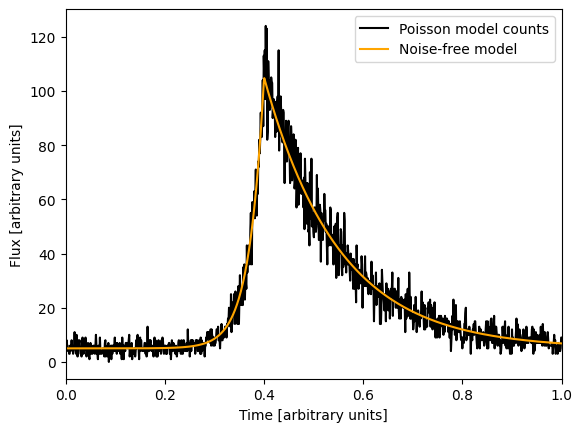

In [4]:
simulator.plot_burst()
plt.show()

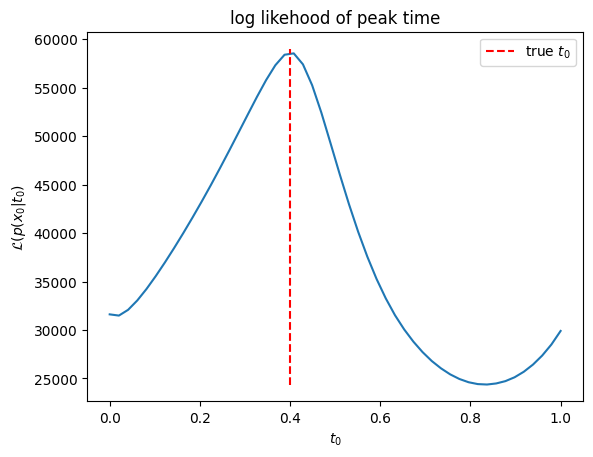

In [5]:
true_t0 = simulator.get_true('t0')

modelparams = {
    'time' : time,
    'ncomp': N,
    'burstparams': burstparams,
    'ybkg': ybkg
}

prior_dict = get_prior_dict(N)

t0s = np.linspace(0, 1, 50)
likelihoods = [log_likelihood([t0], inf_params, prior_dict, modelparams, simulated_counts) for t0 in t0s]

plt.plot(t0s, likelihoods)
plt.title("log likehood of peak time")
plt.ylabel("$\mathcal{L}(p(x_0 | t_0)$")
plt.xlabel("$t_0$")
plt.vlines([true_t0],  ymin=min(likelihoods), ymax=max(likelihoods) + 500, linestyles="dashed", color ='red', label='true $t_0$')
plt.legend()
plt.show()

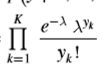

In [6]:
nwalkers = 20
ndim = len(inf_params) * N

p0 = [prior_dict[key].sample(nwalkers) for key in inf_params]
p0 = np.concatenate(p0, axis=1)

# https://emcee.readthedocs.io/en/stable/tutorials/quickstart/
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=[inf_params, prior_dict, modelparams, simulated_counts])

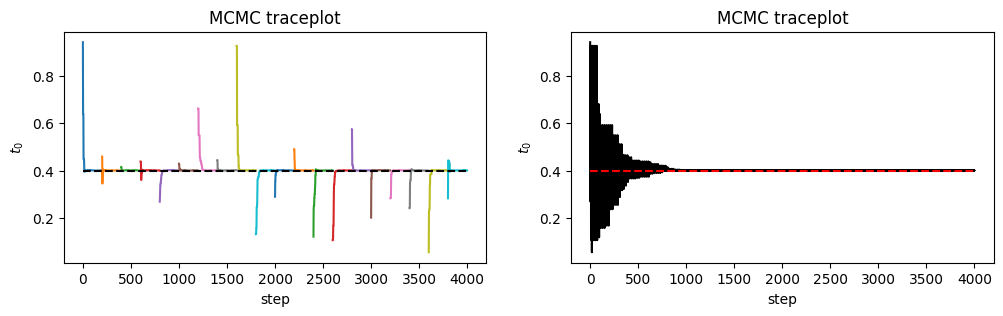

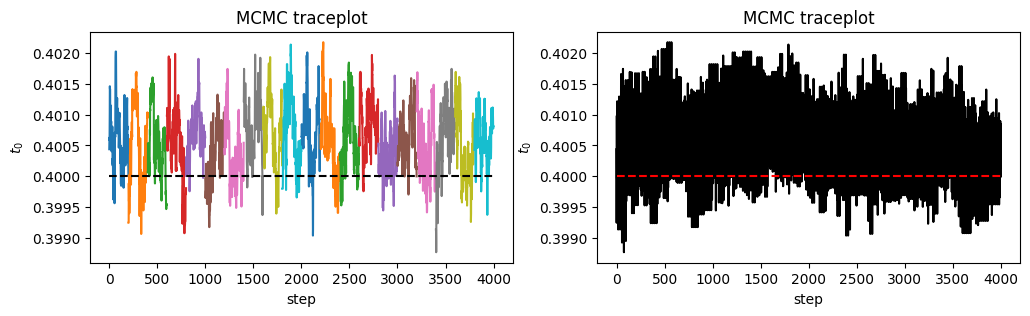

In [ ]:
# burn-in 
burn_steps = 200
state = sampler.run_mcmc(p0, burn_steps)
plot_trace(sampler, burn_steps, true_t0)
sampler.reset()

# correct walkers with low likelihood (otherwise likely to get stuck)
rounded_probs = 1000 * np.floor(state.log_prob / 1000)
low_prob_mask = state.log_prob < np.max(rounded_probs)

variations      = np.ones((sum(low_prob_mask), ndim)) * np.random.uniform(low=0.9, high=1.1, size=(sum(low_prob_mask), ndim))
most_likely_pos = state.coords[np.argmax(state.log_prob)]
state.coords[low_prob_mask] = most_likely_pos * variations

# burn-in with repositioned walkers 
state = sampler.run_mcmc(state, burn_steps)
plot_trace(sampler, burn_steps, true_t0)
sampler.reset()

In [8]:
steps = 1000
sampler.run_mcmc(state, 1000, progress=True)

  2%|▏         | 23/1000 [00:00<00:04, 221.63it/s]

100%|██████████| 1000/1000 [00:03<00:00, 305.45it/s]


State([[0.40028485]
 [0.40048087]
 [0.40161595]
 [0.4003259 ]
 [0.40043827]
 [0.39998573]
 [0.40037334]
 [0.40081126]
 [0.39955679]
 [0.40165395]
 [0.40046891]
 [0.40057353]
 [0.40088465]
 [0.4005782 ]
 [0.40071558]
 [0.40083782]
 [0.39959061]
 [0.40055698]
 [0.40105367]
 [0.40008777]], log_prob=[58653.2988271  58653.40651799 58651.38791225 58653.33206449
 58653.39419676 58652.88582975 58653.36346733 58653.29161516
 58651.76494285 58651.23332696 58653.4036866  58653.41186051
 58653.21572755 58653.41135333 58653.36313239 58653.26625707
 58651.87610985 58653.41306102 58652.97177237 58653.06055207], blobs=None, random_state=('MT19937', array([ 133212860, 1975796708, 4234749297, 3262854109, 1221634125,
       3805393147,   47127794,  687050317, 3608021886,  888349109,
       3629238305,  959143465, 2427921488, 1307350836, 2584408659,
       3483553471, 2853822174, 2143380115, 4213375076,  120824093,
       3237378856, 1758709248,  391893445,  298209812, 3798300650,
       1759058208, 14163

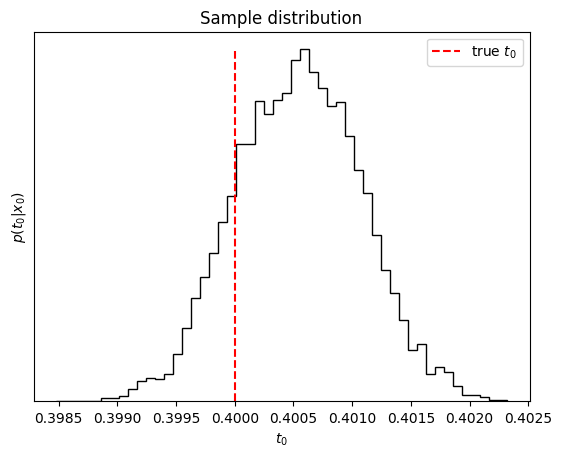

In [9]:
samples = sampler.get_chain(flat=True)

plt.figure()
plot_1d_hist(samples, true_t0)

In [10]:
print(
    "Mean acceptance fraction: {0:.3f}".format(
        np.mean(sampler.acceptance_fraction)
    )
)

# TODO: Diagnose mcmc Trace plots chains as a func of iteration (ideally should be white noise)
# Autocorrelation time check

Mean acceptance fraction: 0.806


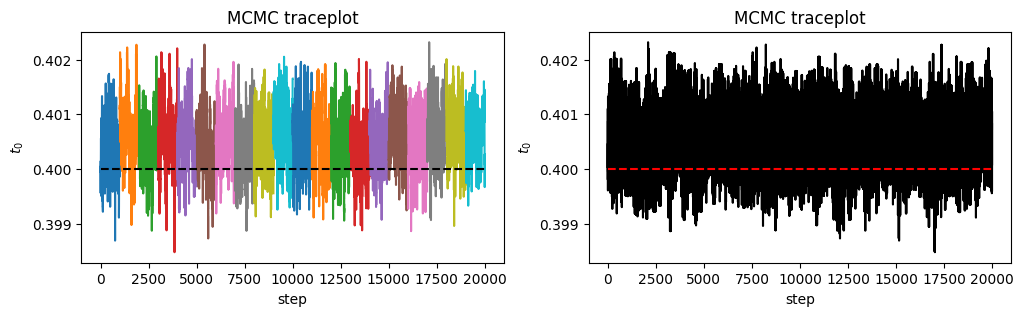

In [11]:
# trace plot
plot_trace(sampler, steps, true_t0)
plt.show()

# Two peaks

The same as before, but we add a burst component, such that N=2 and we have to infer 2 peaktimes.

In [20]:
time = np.linspace(0, 1, 1000)

# NOTE: can change this to whichever N and inf_params you like
N = 2
inf_params = ["t0"]

amp  = [100.0 for _ in range(N)]
t0   = np.sort(np.random.rand(N))
rise = [0.03 for _ in range(N)]
skew = [5.0 for _ in range(N)]

burstparams = {
    't0'   : t0,
    'amp'  : amp,
    'rise' : rise,
    'skew' : skew
    }

modelparams = {
    'time' : time,
    'ncomp': N,
    'burstparams': burstparams,
    'ybkg': ybkg
}

model = Model(time, N, burstparams, ybkg)
simulator = BurstSimulator(model)
x_model, simulated_counts = simulator.simulate_burst(return_model=True)

true_values = np.array([simulator.get_true(key) for key in inf_params])
true_values = true_values.flatten()

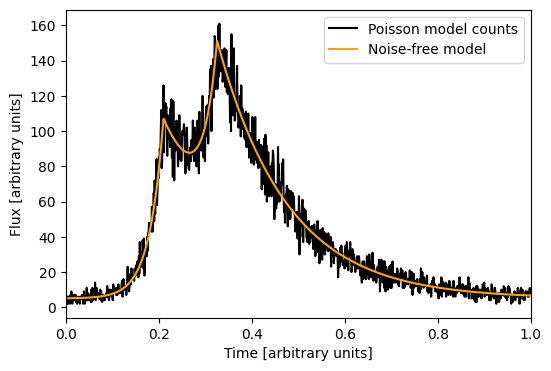

In [21]:
plt.figure(figsize=(6,4))
simulator.plot_burst()
plt.show()

In [22]:
prior_dict = get_prior_dict(N)

nwalkers = 30
ndim = len(inf_params) * N

p0 = [prior_dict[key].sample(nwalkers) for key in inf_params]
p0 = np.concatenate(p0, axis=1)

# https://emcee.readthedocs.io/en/stable/tutorials/quickstart/
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=[inf_params, prior_dict, modelparams, simulated_counts])

In [ ]:
# burn-in of 100 steps
burn_steps = 300
steps = 2000

state = sampler.run_mcmc(p0, burn_steps)
sampler.reset()

# correct walkers with low likelihood (otherwise likely to get stuck)
rounded_probs = 1000 * np.floor(state.log_prob / 1000)
low_prob_mask = state.log_prob < np.max(rounded_probs)

variations      = np.ones((sum(low_prob_mask), ndim)) * np.random.uniform(low=0.9, high=1.1, size=(sum(low_prob_mask), ndim))
most_likely_pos = state.coords[np.argmax(state.log_prob)]
state.coords[low_prob_mask] = most_likely_pos * variations

# burn-in with repositioned walkers 
state = sampler.run_mcmc(state, burn_steps)

sampler.reset()

# running the samples
sampler.run_mcmc(state, steps, progress=True)

100%|██████████| 2000/2000 [00:09<00:00, 206.50it/s]


State([[0.20971585 0.32303007]
 [0.21002348 0.32510672]
 [0.21048816 0.32466171]
 [0.20958494 0.32420737]
 [0.20926651 0.32437975]
 [0.21048737 0.32463862]
 [0.20933437 0.32470699]
 [0.20973728 0.32447486]
 [0.20933166 0.3247668 ]
 [0.20958372 0.32493982]
 [0.20916216 0.32423492]
 [0.21019151 0.32498563]
 [0.20903292 0.32448518]
 [0.21010843 0.32569324]
 [0.21066865 0.32675179]
 [0.20923815 0.32427917]
 [0.21025453 0.32341185]
 [0.20985402 0.32373455]
 [0.21018875 0.32394506]
 [0.20960589 0.32456004]
 [0.21019371 0.32426759]
 [0.21061689 0.32431427]
 [0.21025159 0.32403144]
 [0.21011804 0.32463816]
 [0.21057219 0.32410575]
 [0.20973508 0.32414287]
 [0.20972389 0.32515886]
 [0.21009241 0.32438944]
 [0.20969485 0.32581544]
 [0.20918956 0.32620318]], log_prob=[128467.46694658 128469.822882   128469.25848631 128469.54198103
 128469.17445694 128469.25527202 128469.40309051 128469.83433322
 128469.39519242 128469.72565465 128468.84654884 128469.7974543
 128468.63877503 128469.22201484 128466

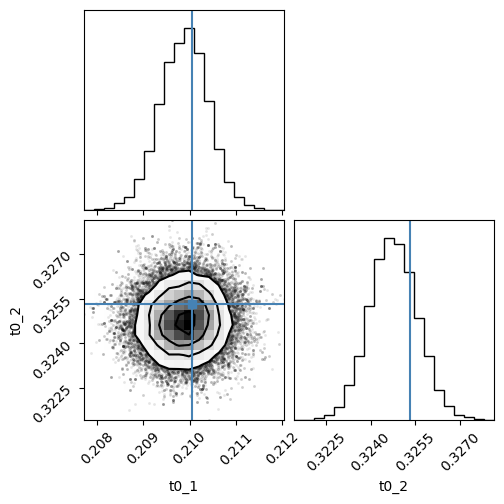

In [24]:
labels = gen_parameter_labels(inf_params, N)
samples = sampler.get_chain(flat=True)
fig = corner(samples, labels=labels, truths=true_values)

In [25]:
print(
    "Mean acceptance fraction: {0:.3f}".format(
        np.mean(sampler.acceptance_fraction)
    )
)
tau = sampler.get_autocorr_time()
tau

Mean acceptance fraction: 0.716


array([25.98475391, 26.39780423])

[0.21005284 0.32530687]


Text(0.5, 0, 'step number')

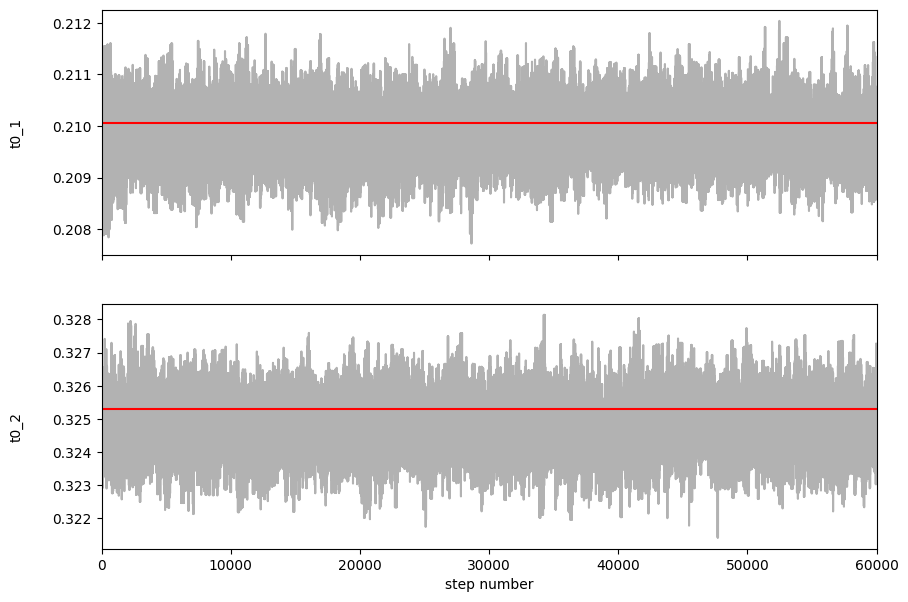

In [26]:
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
labels = gen_parameter_labels(inf_params, N)
print(true_values)
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, i], "k-", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.hlines([true_values[i]], xmin=0, xmax=2*nwalkers*steps, color='red')
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number")

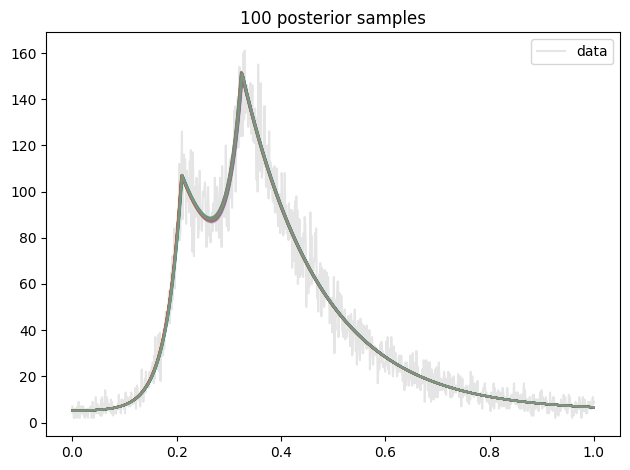

In [27]:
# Draw samples from posterior and overlay onto simulated data
N_samples = 100
plot_posterior_samples(N_samples, simulated_counts, samples, inf_params, modelparams)
plt.tight_layout()